<a href="https://colab.research.google.com/github/riya-nitnaware/riya-nitnaware.ML-LAB/blob/main/Prac_10_ML_Riya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Riya Nitnaware**

**Practical No. 10**

**Aim: To perform Hierarchical Clustering using agglomerative
methods and interpret dendrograms for cluster formation.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML_Dataset/Mall_Customers.csv"
df=pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

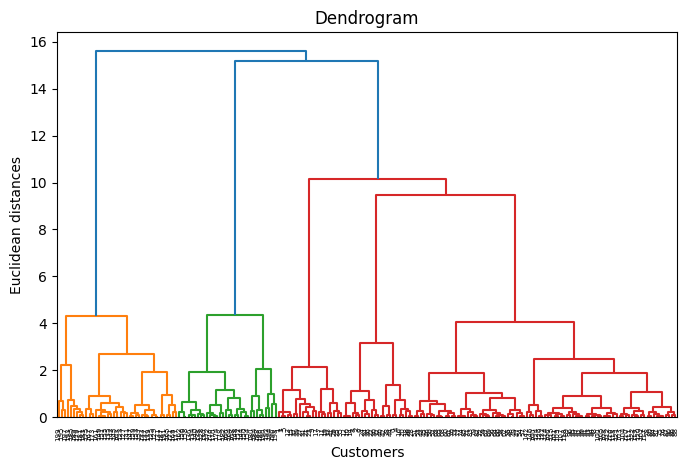

In [ ]:
plt.figure(figsize=(8, 5))
dendrogram(linkage(x_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
cluster = hc.fit_predict(x_scaled)

In [ ]:
df['cluster'] = cluster
print(df.head(5))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


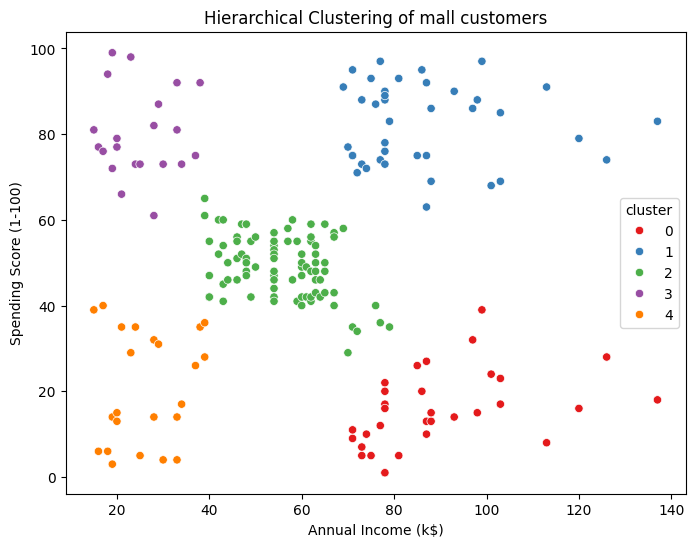

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', data=df, palette='Set1')
plt.title('Hierarchical Clustering of mall customers')
plt.show()